In [53]:
import numpy as np
import random
import matplotlib.pyplot as plt
from dataclasses import dataclass

In [249]:
@dataclass
class MarketConfig:
    start_price: float = 100.0
    drift: float = 0.0
    base_vol: float = 0.3
    dt: float = 0.1
    total_time: int = 1000
        
    lambda_poisson: float = 15
    order_persistence: float = 0.7
    impact_score: float = 0.05
        
    tick: float = 0.01
    spread: float = 0.2
    quote_size: int = 1
    inventory_gamma: float = 0.01
        
    toxicity_alpha: float = 0.3
    kappa: float = 3
    k: float = 8

In [235]:
class MarketPrice:
    def __init__(self, config: MarketConfig):
        self.config = config
        self.mid_price = config.start_price
        self.price_history = [self.mid_price]
        
    def StohasticsPrice(self):
        noise = np.random.normal()
        change = (self.config.drift*self.config.dt) + (self.config.base_vol*np.sqrt(self.config.dt)*noise)
        self.mid_price += change
        return self.mid_price
    
    def PricePlot(self, price):
        plt.figure(figsize=(10, 5)) # Explicitly instantiate figure 1
        plt.plot(price, alpha=0.7, color='blue', label='Mid Price')
        plt.axhline(y=100, color='green', linestyle='--', alpha=0.5, label='Start Price')
        plt.title("Market Making Mid-Price Simulation (Arithmetic)")
        plt.xlabel("Time Steps")
        plt.ylabel("Price")
        plt.legend()
        plt.grid(True, alpha=0.3)
        # Removed plt.show() from he

In [236]:
class OrderFlow:
    def __init__(self, config: MarketConfig):
        self.config = config
        self.last_side = None
        
    def PoissonGeneration(self):
        prob_arrive = 1 - np.exp(-self.config.lambda_poisson*self.config.dt)
        return np.random.rand() < prob_arrive
    
    def TraderType(self):
        return np.random.rand() < self.config.toxicity_alpha
    
    def OrderSide(self):
        if self.last_side == None:
            side = np.random.choice(['buy', 'sell'])
        else:
            if np.random.rand() < self.config.order_persistence:
                side = self.last_side
            else:
                side = 'sell' if self.last_side == 'buy' else 'buy'
        
        self.last_side = side
        return side

In [237]:
class MarketMaker:
    def __init__(self, config: MarketConfig):
        self.config = config
        self.cash = 0.0
        self.inventory = 0
        
        self.recent_trades = []
        self.inventory_history = [0]
        self.pnl_history = [0.0]  # Initial wealth baseline
        
    def Toxicity(self):
        window = self.recent_trades[-10:]
        if len(window) < 5:
            return 0.0
        
        buys = sum(1 for side in window if side == 'buy')
        sells = sum(1 for side in window if side == 'sell') # fixed variable name 'asks' to 'sells'
        imbalance = abs(buys - sells) / len(window)
        
        return imbalance
        
    def Quote(self, mid_price):
        # Avellaneda-Stoikov reservation price skew
        skewed_mid = mid_price - (self.inventory * self.config.inventory_gamma)
        
        hat_alpha = self.Toxicity()
        
        # 🚀 FIXED: Changed '+' to '*' so spread scales naturally
        dynamic_spread = self.config.spread * (1.0 + self.config.kappa * hat_alpha)
        
        half_spread = dynamic_spread / 2.0
        
        # Microstructure tick discretization
        bid = np.floor((skewed_mid - half_spread) / self.config.tick) * self.config.tick
        ask = np.ceil((skewed_mid + half_spread) / self.config.tick) * self.config.tick
        
        # Return hat_alpha so your simulator loop can unpack it cleanly!
        return bid, ask
    
    def ExecuteTrade(self, side, bid, ask):
        if side == 'buy':
            self.inventory -= self.config.quote_size
            self.cash += ask * self.config.quote_size
        elif side == 'sell':
            self.inventory += self.config.quote_size
            self.cash -= bid * self.config.quote_size
            
        self.recent_trades.append(side)
        self.inventory_history.append(self.inventory)
        
    def update_pnl(self, current_mid):
        total_wealth = self.cash + self.inventory * current_mid
        # 🚀 FIXED: Removed 'self.pnl_history.append' from here 
        # let your Simulator manage the logging array to avoid double-appending.
        return total_wealth
    
    def PnLPlot(self, wealth):
        plt.figure(figsize=(10, 5)) # Explicitly instantiate figure 2
        plt.plot(wealth, color='green', linewidth=2, label='Mark-to-Market PnL')
        plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Breakeven Baseline')
        plt.title("Market Making Strategy Performance Equity Curve", fontsize=12, fontweight='bold')
        plt.xlabel("Simulation Ticks / Time Steps")
        plt.ylabel("Total Wealth Value ($)")
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend(loc='upper left')
        
        plt.tight_layout()
        plt.show()

In [238]:
class Simulator:
    def __init__(self, config: MarketConfig):
        self.config = config
        self.price_engine = MarketPrice(config=config)
        self.flow_engine = OrderFlow(config=config)
        self.mm_engine = MarketMaker(config=config)
        
        self.start_time = 0
        self.price_history = [self.config.start_price]
        self.time_history = [0.0]
        
    def run(self):
        while self.start_time < self.config.total_time:
            old_mid = self.price_engine.mid_price
            mid_price = self.price_engine.StohasticsPrice()
            price_delta = mid_price - old_mid
            
            bid, ask = self.mm_engine.Quote(mid_price)
            
            
            if self.flow_engine.PoissonGeneration():
                is_informed = self.flow_engine.TraderType()

                if is_informed:
                    side = 'buy' if price_delta > 0 else 'sell'
                    actual_impact = self.config.impact_score*3
                    event_tag = "⚠️ TOXIC"
                else:
                    side = self.flow_engine.OrderSide()
                    actual_impact = self.config.impact_score*1
                    event_tag = "👤 NOISE"
                    
                if side == 'buy':
                    # An outside buyer wants to buy from your Ask quote
                    delta = ask - mid_price
                else:
                    # An outside seller wants to hit your Bid quote
                    delta = mid_price - bid
                    
                fill_prob = np.exp(-self.config.k * delta)
                
                if np.random.rand() < fill_prob:

                    self.mm_engine.ExecuteTrade(side, bid, ask)

                    impact_dir = 1 if side == 'buy' else -1
                    self.price_engine.mid_price += impact_dir * actual_impact

                    current_mid = self.price_engine.mid_price
#                     event_msg = f"{event_tag} {side.upper()} @ ${ask if side=='buy' else bid:.2f}"
                else:
    #                 event_msg = "(no trade)"
                    pass
            else:
                pass
            current_pnl = self.mm_engine.update_pnl(mid_price)
            current_inv = self.mm_engine.inventory

            self.price_history.append(mid_price)
            self.mm_engine.inventory_history.append(current_inv)
            self.mm_engine.pnl_history.append(current_pnl) # This is where the single, clean append happens!

            self.time_history.append(self.start_time)
            self.start_time += self.config.dt
            
        # --- END OF LOOP ---
        # Now pass the fully populated lists straight into your plotting engines!
        self.price_engine.PricePlot(self.price_history)
        self.mm_engine.PnLPlot(self.mm_engine.pnl_history)

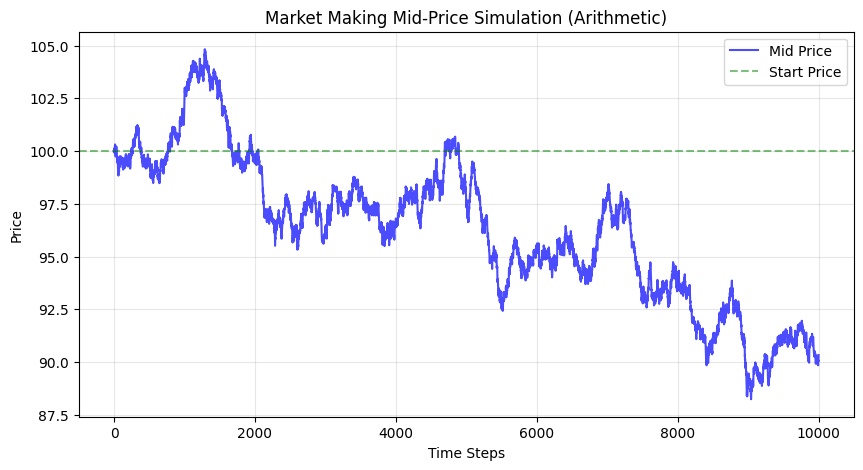

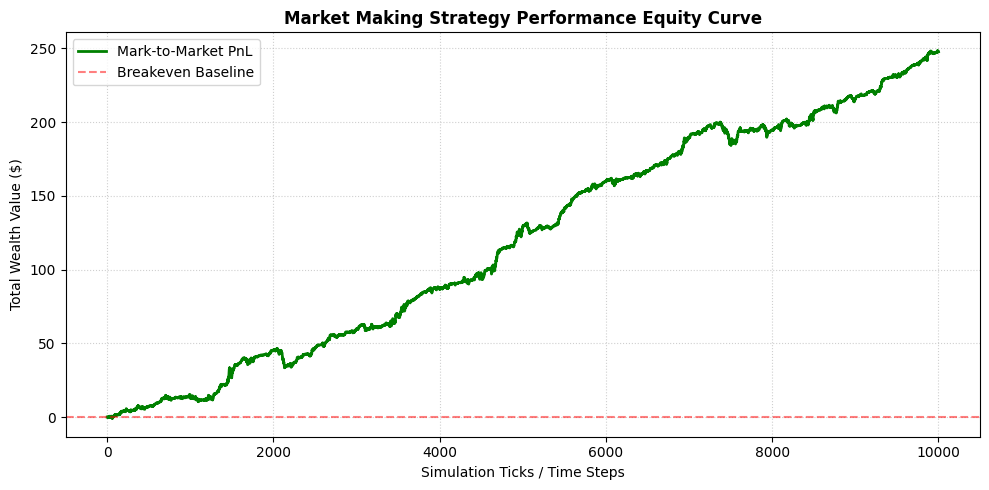

In [250]:
config = MarketConfig()
sim = Simulator(config=config)
sim.run()